# Portfolio Lab — EUR investor study

Run top to bottom after package installation. All calculations and safeguards live in portfolio_lab. No prices or FX are forward-filled.

In [10]:
from dataclasses import replace
from pathlib import Path
from IPython.display import display, Image
from portfolio_lab.config import load_config, configure_universe
from portfolio_lab.data import load_market_data, study_coverage
from portfolio_lab.leverage import add_leverage
from portfolio_lab.metrics import compute_asset_metrics
from portfolio_lab.optimization import optimize_frontier
from portfolio_lab.plotting import plot_frontier, plot_drawdown, allocation_summary
from portfolio_lab.reporting import format_weights, write_review_outputs

project_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()


## User configuration
Select display names, registered tickers and leverage below. Financial metadata lives in `src/portfolio_lab/assets.py`. Run All after every change.

In [11]:
assets = {
    "Apple": "AAPL",
    "Nasdaq 100": "QQQ",
    "S&P 500": "^SP500TR",
    "Dow Jones": "DIA",
    # "CAC 40": "PX1GR.PA",
    "Gold": "GC=F",
    "MSCI World": "MSCI:990100:NETR",
    # "Obligation": "IBGS.AS",
}

# {} or None = no leverage. Example: {"Apple": 1.5, "Nasdaq 100": 2.0}
leveraged_assets = {}

config = configure_universe(load_config(project_dir), assets, leveraged_assets)
# Optional study overrides:
# config = replace(config, risk_free_rate=0.02, frontier_points=75)


## Market data and provenance

Adjusted equity prices are a reinvestment proxy. Gross-return indices incorporate gross dividends. Gold futures quotations are not an investable total-return benchmark.

In [12]:
data = load_market_data(config)
display(data.provenance)
display(data.fx_sample)
display(study_coverage(data, config))


,Provider,Symbol,Source detail,Instrument / benchmark,Return type,Native currency,Converted to,FX series used,Raw start date,Raw end date,Raw observations,Raw missing observations,FX missing on observed sessions,EUR observations,Final common start,Final common end,Final common observations,Distributions,Limitation,Reference
Asset,,,,,,,,,,,,,,,,,,,,
Apple,Yahoo Finance,AAPL,,Primary US equity,Adjusted price,USD,EUR,EURUSD=X,1980-12-12,2026-10-02,11544,0,5828,5716,2003-12-01,2026-10-02,5703,Yahoo split/dividend adjustment; reinvestment ...,"Adjusted prices are a vendor proxy, not an ind...",
Nasdaq 100,Yahoo Finance,QQQ,,Invesco QQQ ETF; Nasdaq-100 exposure proxy,Adjusted price,USD,EUR,EURUSD=X,1999-03-10,2026-10-02,6935,0,1219,5716,2003-12-01,2026-10-02,5703,Yahoo dividend/split adjustments; distribution...,Exact Nasdaq-100 TR unavailable from tested Ya...,https://www.invesco.com/qqq-etf/en/home.html
S&P 500,Yahoo Finance,^SP500TR,,S&P 500 Total Return index,Gross Return,USD,EUR,EURUSD=X,1988-01-04,2026-10-02,9761,0,4045,5716,2003-12-01,2026-10-02,5703,Gross dividends reinvested by index methodology,,https://www.spglobal.com/spdji/en/indices/equi...
Dow Jones,Yahoo Finance,DIA,,State Street SPDR Dow Jones Industrial Average...,Adjusted price,USD,EUR,EURUSD=X,1998-01-20,2026-10-02,7221,0,1505,5716,2003-12-01,2026-10-02,5703,Yahoo dividend/split adjustments; distribution...,Exact Dow Jones TR unavailable from tested Yah...,https://www.ssga.com/us/en/individual/etfs/sta...
Gold,Yahoo Finance,GC=F,,Yahoo continuous COMEX gold futures quotation,Price Return,USD,EUR,EURUSD=X,2000-08-30,2026-10-02,6548,83,840,5708,2003-12-01,2026-10-02,5703,No dividends; quoted futures price changes only,Not spot gold or an investable futures total-r...,
MSCI World,MSCI,MSCI:990100:NETR,MSCI index code 990100; variant NETR (Net Tota...,"MSCI World Index (index code 990100), Net Tota...",Net Total Return,USD,EUR,EURUSD=X,2000-12-29,2026-10-02,6721,0,795,5926,2003-12-01,2026-10-02,5703,Net dividends reinvested according to MSCI ind...,Official index rather than ETF prices; exclude...,https://www.msci.com/indexes/index/990100/msci...


,USD value,EURUSD,Computed EUR value
Date,,,
2003-12-01,0.324669,1.196501,0.271349
2003-12-02,0.322127,1.208897,0.266463
2003-12-03,0.314500,1.212298,0.259425
2003-12-04,0.316295,1.208094,0.261813
2003-12-05,0.311807,1.218695,0.255854


{'common_start': '2003-12-01',
 'common_end': '2026-10-02',
 'common_observations': 5703,
 'latest_raw_asset_start': '2000-12-29',
 'raw_start_limiting_assets': ['MSCI World'],
 'earliest_raw_asset_end': '2026-10-02',
 'raw_end_limiting_assets': ['Apple',
  'Nasdaq 100',
  'S&P 500',
  'Dow Jones',
  'Gold',
  'MSCI World'],
 'latest_eur_asset_start': '2003-12-01',
 'eur_start_limiting_assets': ['Apple',
  'Nasdaq 100',
  'S&P 500',
  'Dow Jones',
  'Gold',
  'MSCI World'],
 'start_limiting_series': ['EURUSD=X'],
 'fx_start': '2003-12-01',
 'first_common_date_delayed_by_calendar': False}

## Daily-reset synthetic assets

Reset on every native underlying session, then translate NAV into EUR with unlevered FX. Compound before sampling common dates.

In [13]:
prices, leverage_diagnostics = add_leverage(data.common, data.native, data.fx, config)
display(leverage_diagnostics)

""


## Asset performance in EUR

In [14]:
stats = compute_asset_metrics(prices, config.trading_days, config.risk_free_rate, config.calendar_days_per_year)
display(stats)

,CAGR,Mean return annualized,Volatility annualized,Max Drawdown,Sharpe,Calmar
Asset,,,,,,
Apple,0.358509,0.366721,0.338950,-0.565253,1.081933,0.634244
Nasdaq 100,0.154087,0.171989,0.233665,-0.468036,0.736050,0.329220
Gold,0.110683,0.125308,0.196629,-0.373896,0.637283,0.296027
S&P 500,0.114190,0.130230,0.205062,-0.512942,0.635076,0.222617
Dow Jones,0.101231,0.116942,0.197750,-0.466981,0.591359,0.216777
MSCI World,0.095752,0.107928,0.176491,-0.533001,0.611524,0.179647


## Growth frontier and volatility ceilings

Constant weights, long-only; rebalance at each common observation. Leveraged versions replace their underlying in the configured universe.

In [15]:
optimization = optimize_frontier(prices, config)
display(optimization.summary)
display(format_weights(optimization.weights))
display(allocation_summary(optimization.weights, config.allocation_display_threshold))
display(optimization.dominance)

,CAGR,Mean return annualized,Volatility,Max Drawdown,Sharpe,Calmar,Success,Solver status,Status,Risk ceiling
Portfolio,,,,,,,,,,
Minimum Volatility,0.110014,0.116274,0.147716,-0.291954,0.787149,0.376819,True,0,Optimization terminated successfully,NaN
Maximum CAGR,0.358509,0.366721,0.33895,-0.565253,1.081933,0.634244,True,0,Optimization terminated successfully,NaN
Maximum Sharpe,0.257431,0.253521,0.211088,-0.374188,1.201016,0.687973,True,0,Optimization terminated successfully,NaN
Prudent,0.129955,0.134587,0.15,-0.281224,0.897244,0.462103,True,0,Optimization terminated successfully,0.15
Modéré,0.242463,0.239154,0.2,-0.367851,1.195769,0.659135,True,0,Optimization terminated successfully,0.2
Dynamique,0.334549,0.336319,0.3,-0.50449,1.121062,0.663143,True,0,Optimization terminated successfully,0.3
Agressif,0.358509,0.366721,0.33895,-0.565253,1.081933,0.634244,True,0,Maximum CAGR reached; unused risk allowance,0.4
Très agressif,0.358509,0.366721,0.33895,-0.565253,1.081933,0.634244,True,0,Maximum CAGR reached; unused risk allowance,0.5


,Apple,Nasdaq 100,S&P 500,Dow Jones,Gold,MSCI World
Portfolio,,,,,,
Minimum Volatility,0.00%,0.00%,0.00%,9.40%,43.15%,47.45%
Maximum CAGR,100.00%,0.00%,0.00%,0.00%,0.00%,0.00%
Maximum Sharpe,53.11%,0.00%,0.00%,0.00%,46.89%,0.00%
Prudent,6.95%,0.00%,0.00%,9.37%,45.07%,38.62%
Modéré,47.16%,0.00%,0.00%,0.00%,52.84%,0.00%
Dynamique,87.41%,0.00%,0.00%,0.00%,12.59%,0.00%
Agressif,100.00%,0.00%,0.00%,0.00%,0.00%,0.00%
Très agressif,100.00%,0.00%,0.00%,0.00%,0.00%,0.00%


Portfolio
Minimum Volatility       MSCI World 47.5% · Gold 43.1% · Dow Jones 9.4%
Maximum CAGR                                               Apple 100.0%
Maximum Sharpe                                 Apple 53.1% · Gold 46.9%
Prudent               Gold 45.1% · MSCI World 38.6% · Dow Jones 9.4%...
Modéré                                         Gold 52.8% · Apple 47.2%
Dynamique                                      Apple 87.4% · Gold 12.6%
Agressif                                                   Apple 100.0%
Très agressif                                              Apple 100.0%
dtype: object

,100% CAGR,100% volatility,Frontier CAGR,Frontier volatility
Asset,,,,
Apple,0.358509,0.338950,0.358509,0.338950
Nasdaq 100,0.154087,0.233665,0.281929,0.233665
S&P 500,0.114190,0.205062,0.249653,0.205062
Dow Jones,0.101231,0.197750,0.239033,0.197750
Gold,0.110683,0.196629,0.237293,0.196629
MSCI World,0.095752,0.176491,0.202959,0.176491


## Charts

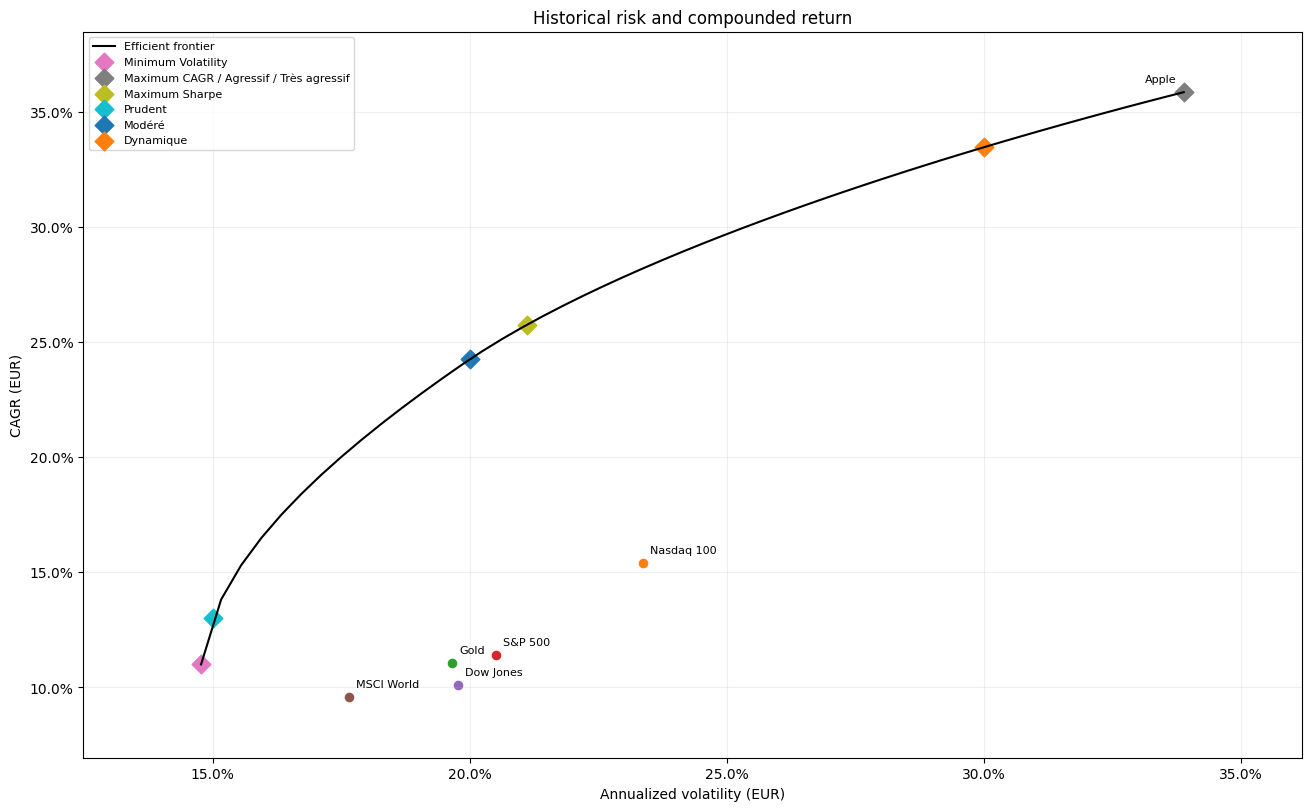

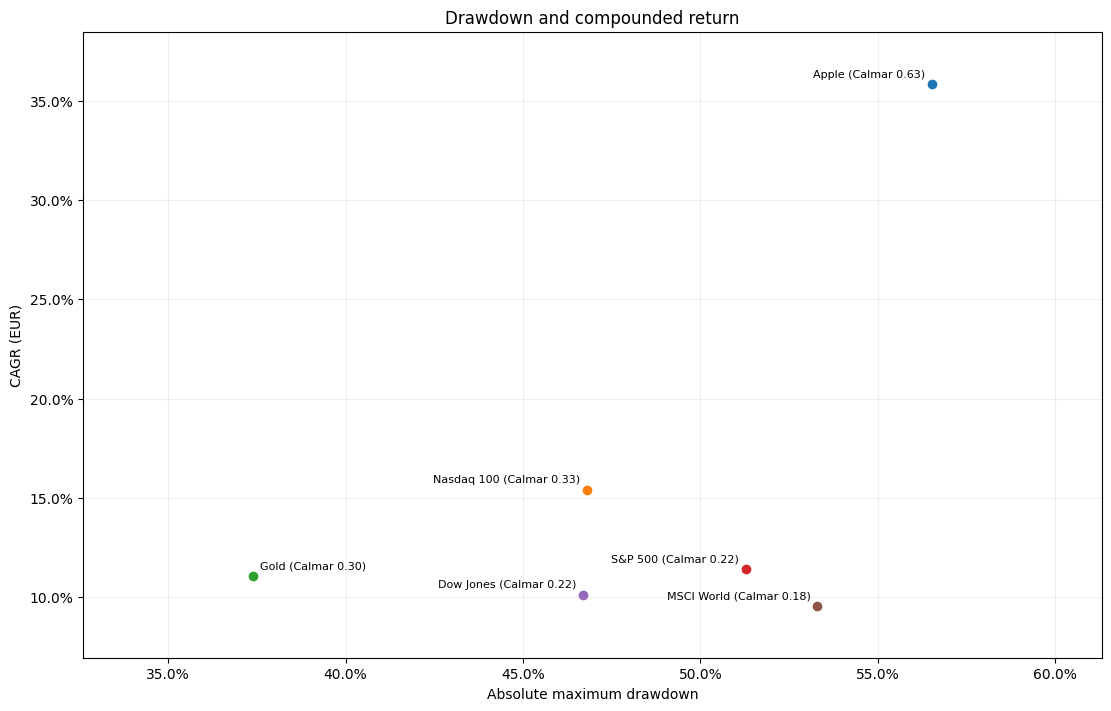

In [16]:
frontier_figure = plot_frontier(stats, optimization)
drawdown_figure = plot_drawdown(stats)

## Export evidence and validate numerical results

{'portfolio_weight_sums': {'Minimum Volatility': 1.0,
  'Maximum CAGR': 1.0,
  'Maximum Sharpe': 1.0,
  'Prudent': 1.0,
  'Modéré': 1.0,
  'Dynamique': 1.0,
  'Agressif': 1.0,
  'Très agressif': 1.0,
  'Frontier 0': 1.0,
  'Frontier 1': 1.0,
  'Frontier 2': 1.0,
  'Frontier 3': 1.0,
  'Frontier 4': 1.0,
  'Frontier 5': 1.0,
  'Frontier 6': 1.0,
  'Frontier 7': 1.0,
  'Frontier 8': 0.9999999999999999,
  'Frontier 9': 1.0,
  'Frontier 10': 1.0,
  'Frontier 11': 1.0,
  'Frontier 12': 1.0,
  'Frontier 13': 1.0,
  'Frontier 14': 1.0,
  'Frontier 15': 1.0,
  'Frontier 16': 1.0,
  'Frontier 17': 1.0,
  'Frontier 18': 1.0,
  'Frontier 19': 1.0,
  'Frontier 20': 1.0,
  'Frontier 21': 1.0,
  'Frontier 22': 1.0,
  'Frontier 23': 1.0,
  'Frontier 24': 0.9999999999999998,
  'Frontier 25': 1.0,
  'Frontier 26': 0.9999999999999999,
  'Frontier 27': 1.0,
  'Frontier 28': 1.0,
  'Frontier 29': 1.0,
  'Frontier 30': 1.0,
  'Frontier 31': 1.0,
  'Frontier 32': 0.9999999999999999,
  'Frontier 33': 1.0,
  

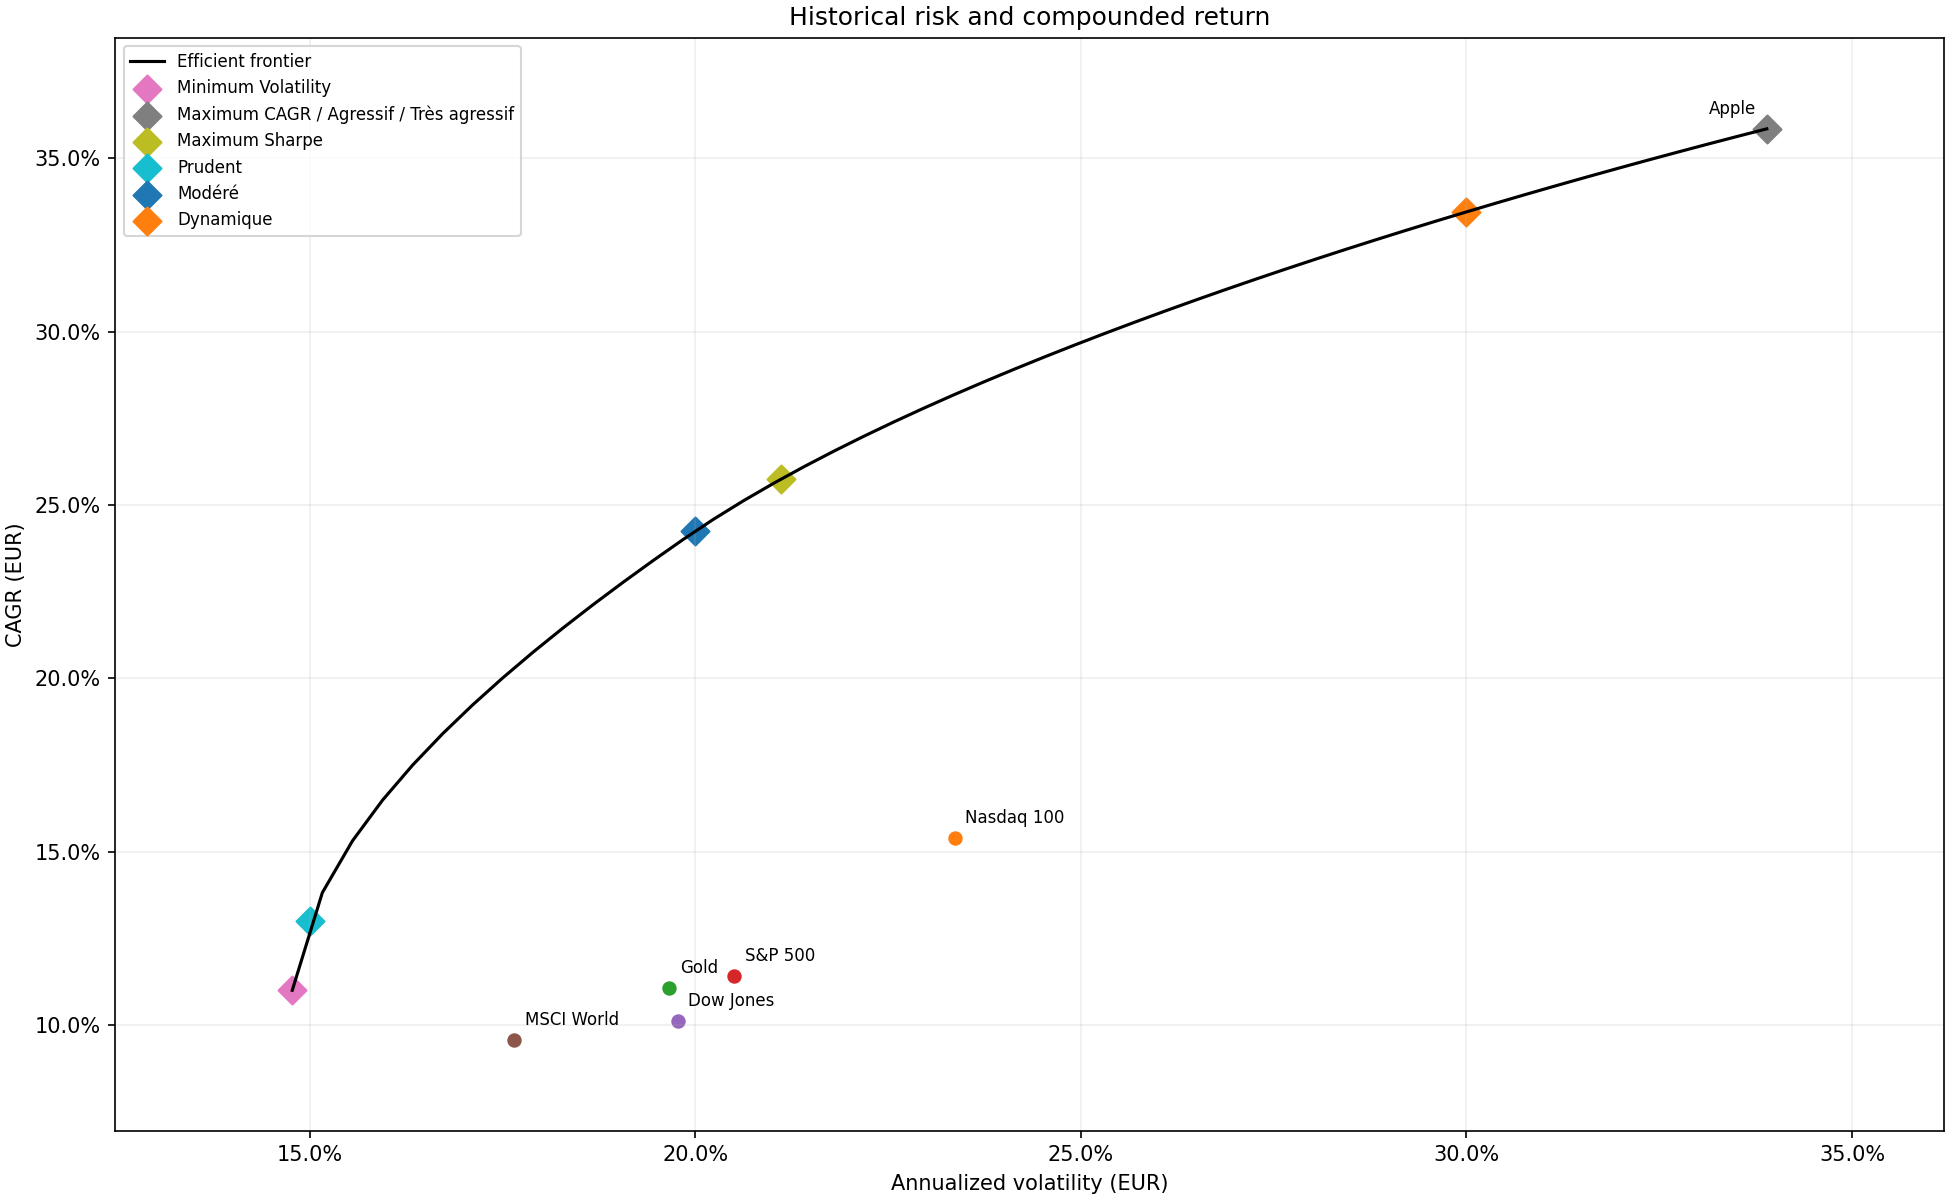

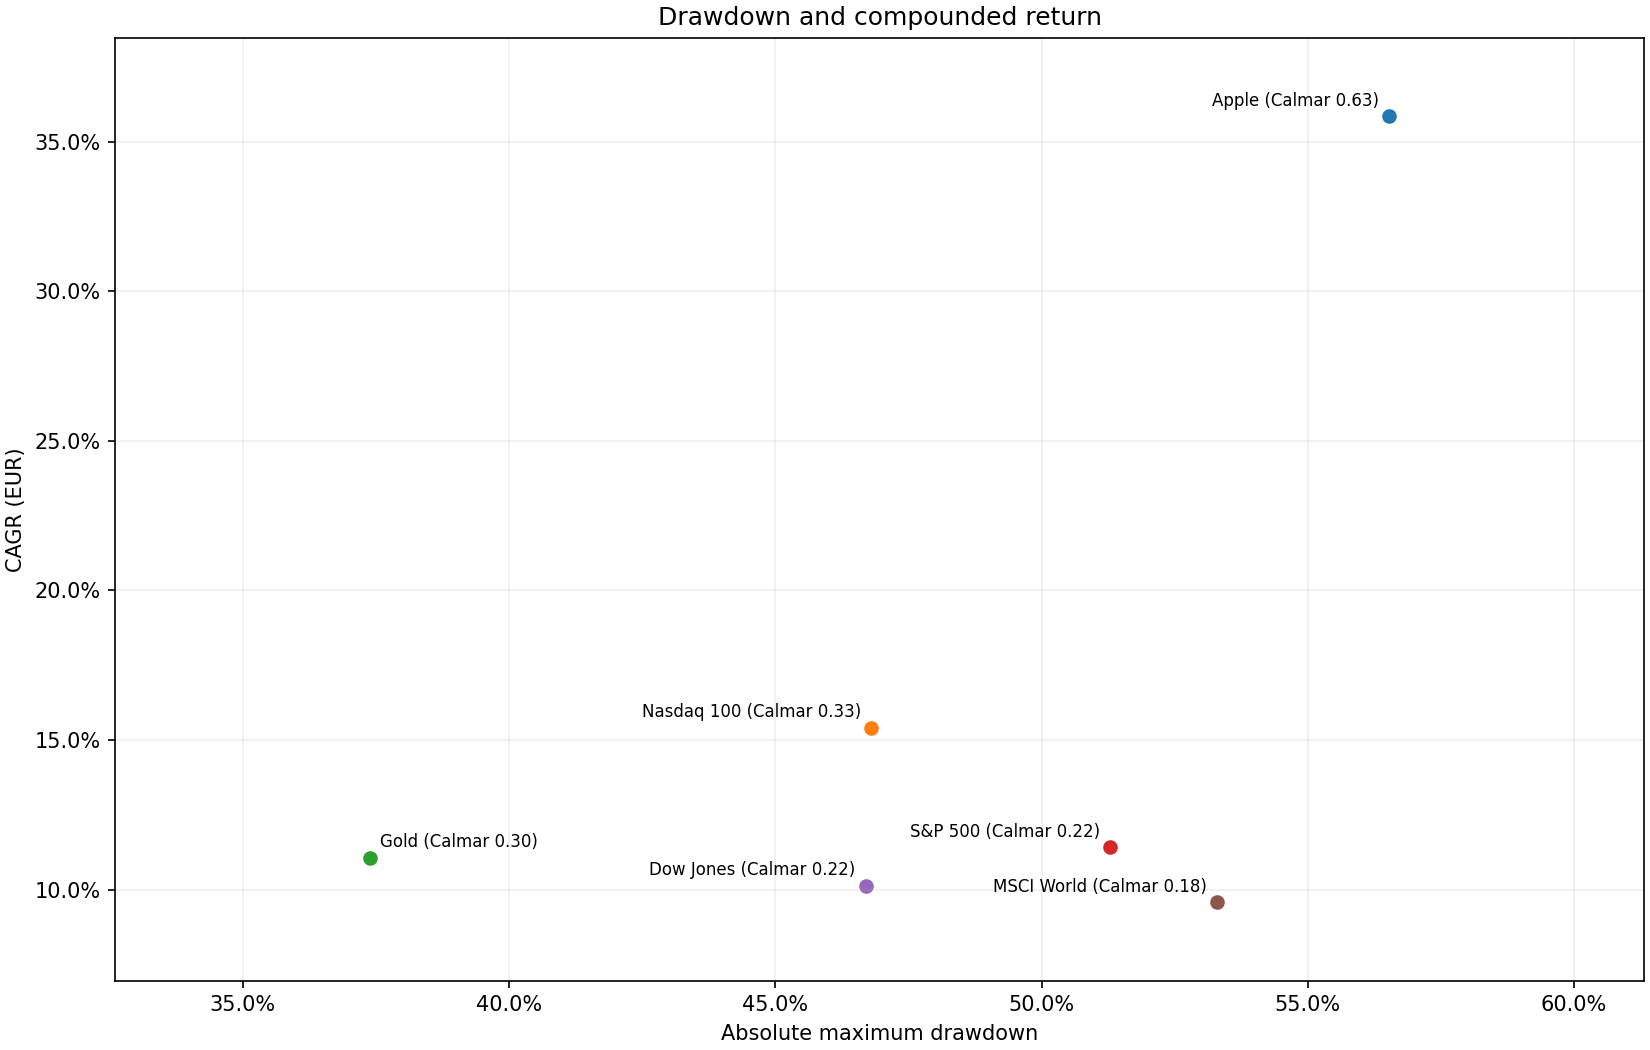

In [17]:
sanity = write_review_outputs(data, prices, stats, leverage_diagnostics, optimization, config)
frontier_figure.savefig(config.output_dir / "frontier.png", dpi=150)
drawdown_figure.savefig(config.output_dir / "drawdown.png", dpi=150)
display(sanity)
display(Image(filename=str(config.output_dir / "frontier.png")))
display(Image(filename=str(config.output_dir / "drawdown.png")))


In [18]:
import yfinance as yf

df = yf.Ticker("EUNL.DE").history(
    period="max",
    interval="1d",
    auto_adjust=False,
)

print(df.index.min())
print(df.index.max())
print(len(df))

2009-09-25 00:00:00+02:00
2026-10-07 00:00:00+02:00
4324
